<h1 style="text-align:center; color:green; font-size:48px;">
OEMOF TUTORIAL
</h1>

### Support functions

In [1]:
# Levelized Cost of Heat

def LCOH(invest_cost, operation_cost, heat_produced, revenue=0, i=0.05, n=20):
    pvf = ((1 + i) ** n - 1) / ((1 + i) ** n * i)

    return (invest_cost + pvf * (operation_cost - revenue)) / (
        pvf * heat_produced
    )
    
# Equivalent Periodic Cost

def epc(invest_cost, i=0.05, n=20):
    af = (i * (1 + i) ** n) / ((1 + i) ** n - 1)

    return invest_cost * af

# Import libraries

In [2]:
import os
import warnings
import logging
import pandas as pd
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model, create_time_index, processing)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)
from oemof.solph import EnergySystem
from oemof.solph import views
import oemof.solph as solph
import sys
!{sys.executable} -m pip install openpyxl



# Example

<img src="Example_OEMOF.png" width="40%">

## 1.1 Create the energy system 

**Scenario Selection:**
- **Scenario A**: Total Cost + Emission Costs (original fuel/operating costs + emission costs)
- **Scenario B**: Emission Costs Only (fuel/operating costs = 0, only emission costs)

**Emission factors (kg CO₂/kWh fuel):**
  - Natural gas: 0.2
  - Biomass: 0.0
  - Grid electricity: 0.35

In [3]:
# read the input data file
filename = r"OEMOF_files/Example_1.csv"
data = pd.read_csv(filename)

# specifying the solver
solver = "cbc"
solver_verbose = False

# Create energy system
datetimeindex = pd.date_range(
    start='2022-01-01 00:00',
    periods=len(data),  # 8760 matches your data
    freq='h'
)
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)

# Add components to the energy system

# Buses - internal_elec_bus representing the electricity generated only by both CHPs
electrical_bus = Bus(label="electrical_bus") # Electricity bus (external grid)
thermal_bus = Bus(label="thermal_bus") # Heating bus
gas_bus = Bus(label="gas_bus") # Natural gas bus
biomass_bus = Bus(label="biomass_bus") # Biomass fuel bus
internal_elec_bus = Bus(label="internal_elec_bus") # Electricity from internal generation (NG and biomass CHPs)

import pandas as pd
from pathlib import Path

co2_cost_kWh = data["co2_price"]/1000

# add emission factors
grid_emission_factor = 0.35
biomass_emission_factor= 0
natural_gas_emission_factor=0.2

grid_co2_cost = grid_emission_factor * co2_cost_kWh 
natural_gas_co2_cost = natural_gas_emission_factor * co2_cost_kWh


# Load the CSV and extract the losses column
csv_path = Path("Outputs") / "STEP_2.results_edges.csv"
absolute_losses = pd.read_csv(csv_path)["losses"]
total_absolute_losses = absolute_losses.sum()
print("Total absolute losses (kW):", round(total_absolute_losses, 2))

energysystem.add(electrical_bus, thermal_bus, gas_bus, biomass_bus, internal_elec_bus)



# Thermal demand (sink) considering the absolute losses
load_kW_nolosses = data["thermal_demand"]
load_kW = data["thermal_demand"] + total_absolute_losses
print("peak thermal demand (kW):", round(load_kW_nolosses.max(), 2))
print("peak thermal demand considering losses (kW):", round(load_kW.max(), 2))
peak = load_kW.max()
energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={thermal_bus: Flow(
            nominal_value= peak,
            fix=load_kW / peak
        )},
    )
)

# Excess electricity sink (only external grid) - Scenario B: no cost
energysystem.add(
    Sink(
        label="excess_electricity",
        inputs={electrical_bus: Flow(
            variable_costs=0,  # Scenario B: no fuel cost
            nominal_value=1e10          
        )}
    )
)

# Excess thermal sink (thermal surplus)
energysystem.add(
    Sink(
        label="excess_thermal",
        inputs={thermal_bus: Flow(
            nominal_value=1e10,       
            variable_costs=0       # INCREASE to penalize the excess heat
        )}
    )
)

# Sink for excess internal electricity (if the CHPs produce more than needed)
energysystem.add(
    Sink(
        label="excess_internal_electricity",
        inputs={internal_elec_bus: Flow(  
            nominal_value=1e10
        )}
    )
)




# Gas source with cost from gas
energysystem.add(
    Source(label="natural_gas",outputs={gas_bus: Flow()}) # costs defined in the converters
)

# Grid electricity source - Scenario B: only emission cost (fuel cost = 0)
energysystem.add(
    Source(label="electricity_grid",outputs={electrical_bus: Flow(variable_costs=0 + grid_co2_cost)})
)






# Biomass source - Scenario B: fuel cost = 0 (emission factor is also 0, so no CO2 cost)
biomass_cost_per_kwh = 0

energysystem.add(
    Source(
        label="biomass_source",
        outputs={
            biomass_bus: Flow() # costs defined in the converters
        },
    )
)




# ----------- CONVERTERS -----------

# Biomass CHP - Scenario B: fuel cost = 0, using fixed capacity from STEP_4
energysystem.add(
    Converter(  
        label="biomass_chp",
        inputs={biomass_bus: Flow(variable_costs=biomass_cost_per_kwh)},  # = 0 in Scenario B
        outputs={
            internal_elec_bus: Flow(),  # --> internal_elec_bus instead of electrical_bus
            thermal_bus: Flow(nominal_value=721.06)  # From STEP_4 optimization
        },
        conversion_factors={
            internal_elec_bus: 0.25,
            thermal_bus: 0.50
        },
    )
)

# Electric Boiler - using fixed capacity from STEP_4
energysystem.add(
    Converter(
        label="electric_boiler",
        inputs={internal_elec_bus: Flow(), electrical_bus: Flow()},  
        outputs={thermal_bus: Flow(nominal_value=367.89)},  # From STEP_4 optimization
        conversion_factors={thermal_bus: 0.99} 
    )
)

# Gas CHP - Scenario B: fuel cost = 0, only emission cost, using fixed capacity from STEP_4
energysystem.add(
    Converter(
        label="chp",
        inputs={gas_bus: Flow(variable_costs=0 + natural_gas_co2_cost)},  # Only emission cost in Scenario B
        outputs={
            internal_elec_bus: Flow(),  # --> internal_elec_bus
            thermal_bus: Flow(nominal_value=233.24),  # From STEP_4 optimization
        },
        conversion_factors={internal_elec_bus: 0.33, thermal_bus: 0.5}
    )
)

# Heat Pump - using fixed capacity from STEP_4
energysystem.add(
    Converter(
        label="heat_pump",
        inputs={internal_elec_bus: Flow(), electrical_bus: Flow()}, 
        outputs={
            thermal_bus: Flow(nominal_value=500.00)  # From STEP_4 optimization
        },
        conversion_factors={thermal_bus: 3.5}
    )
)



Total absolute losses (kW): 3.22
peak thermal demand (kW): 1869.59
peak thermal demand considering losses (kW): 1872.8


### Adding the solar thermal collector to the system

In [4]:
# Loadind irradiance and ambient temperature data
SolarCollector_inputs = pd.read_csv('OEMOF_files/SolarCollector_inputs.csv')
# Extract the columns for global and diffuse horizontal irradiance     
SolarCollector_inputs['Global'] = pd.to_numeric(SolarCollector_inputs['Global'], errors='coerce')

global_horizontal_W_m2 = SolarCollector_inputs['Global']
collector_aperture_area = 1000
collector_efficiency = 0.73

thermal_output = (global_horizontal_W_m2 * collector_aperture_area * collector_efficiency)/1000


In [5]:
thermal_profile = pd.Series(thermal_output.values, index=datetimeindex)

# Align profile length with model intervals (infer_last_interval=False → n-1 intervals)
aligned_profile = thermal_profile.iloc[: len(energysystem.timeindex) - 1]
nominal_value = aligned_profile.max()

# Normalize the fixed profile to [0,1]
fix_profile = aligned_profile / nominal_value

energysystem.add(Source(
    label='solar_collector',
    outputs={
        thermal_bus: Flow(
            nominal_value=nominal_value,
            fix=fix_profile.values   # normalized fixed flow profile as numpy array
        )
    }
))

## 1.2 Build and solve model

In [6]:
model = Model(energysystem)


logging.info("Solving the optimization problem.")
model.solve(
    solver='cbc',
    solve_kwargs={"tee": True},
    cmdline_options={"ratioGap": "0.02"}
)

'''
This returns a dictionary containing time series and scalar results for all components (buses, converters, sources, etc.).
Or view results for a specific node (for example, a bus).
'''

# Process results
energysystem.results["main"] = processing.results(model)
energysystem.results["meta"] = processing.meta_results(model)

# Save results to file
output_file = os.path.join(os.getcwd(), "Outputs/results.oemof")

energysystem.dump(os.getcwd(), "Outputs/results.oemof")

logging.info("Results have been dumped.")

c:\Users\mugol\anaconda3\envs\env_P2\lib\site-packages\oemof\solph\_plumbing.py:82: FutureWarning: Sequence longer than needed (8760 items instead of 8759). This will be trated as an error in the future.
  warnings.warn(


Welcome to the CBC MILP Solver 
Version: 2.10.12 
Build Date: Jul 31 2025 

command line - C:\Users\mugol\anaconda3\envs\env_P2\Library\bin\cbc.exe -ratioGap 0.02 -printingOptions all -import C:\Users\mugol\AppData\Local\Temp\tmpuksns_g7.pyomo.lp -stat=1 -solve -solu C:\Users\mugol\AppData\Local\Temp\tmpuksns_g7.pyomo.soln (default strategy 1)
ratioGap was changed from 0 to 0.02
Option for printingOptions changed from normal to all
Presolve 15534 (-98333) rows, 31068 (-126594) columns and 62136 (-235670) elements
Statistics for presolved model


Problem has 15534 rows, 31068 columns (23301 with objective) and 62136 elements
Column breakdown:
0 of type 0.0->inf, 31068 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 0 of type 0.0->1.0 
Row breakdown:
0 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
0 of type E other, 0 of type G 0.0, 0 of type G 1.0, 
0 of type G other, 0 of type L 0.0, 0 of type L 1.0,

c:\Users\mugol\anaconda3\envs\env_P2\lib\site-packages\oemof\network\energy_system.py:256: FutureWarning: Parameter 'dpath' will be removed in a future version. You can give the directory as part of the filename and set 'consider_dpath' to False to suppress this waring.
  warnings.warn(


## 1.3 Results

In [7]:
energysystem.results

results = energysystem.results["main"]

# get all variables of a specific component/bus
thermal_results = views.node(results, "thermal_bus")
storage_results = views.node(results, "storage")
electrical_results = views.node(results, "electrical_bus")
internal_elec_results = views.node(results, "internal_elec_bus")

### Analyse thermal node

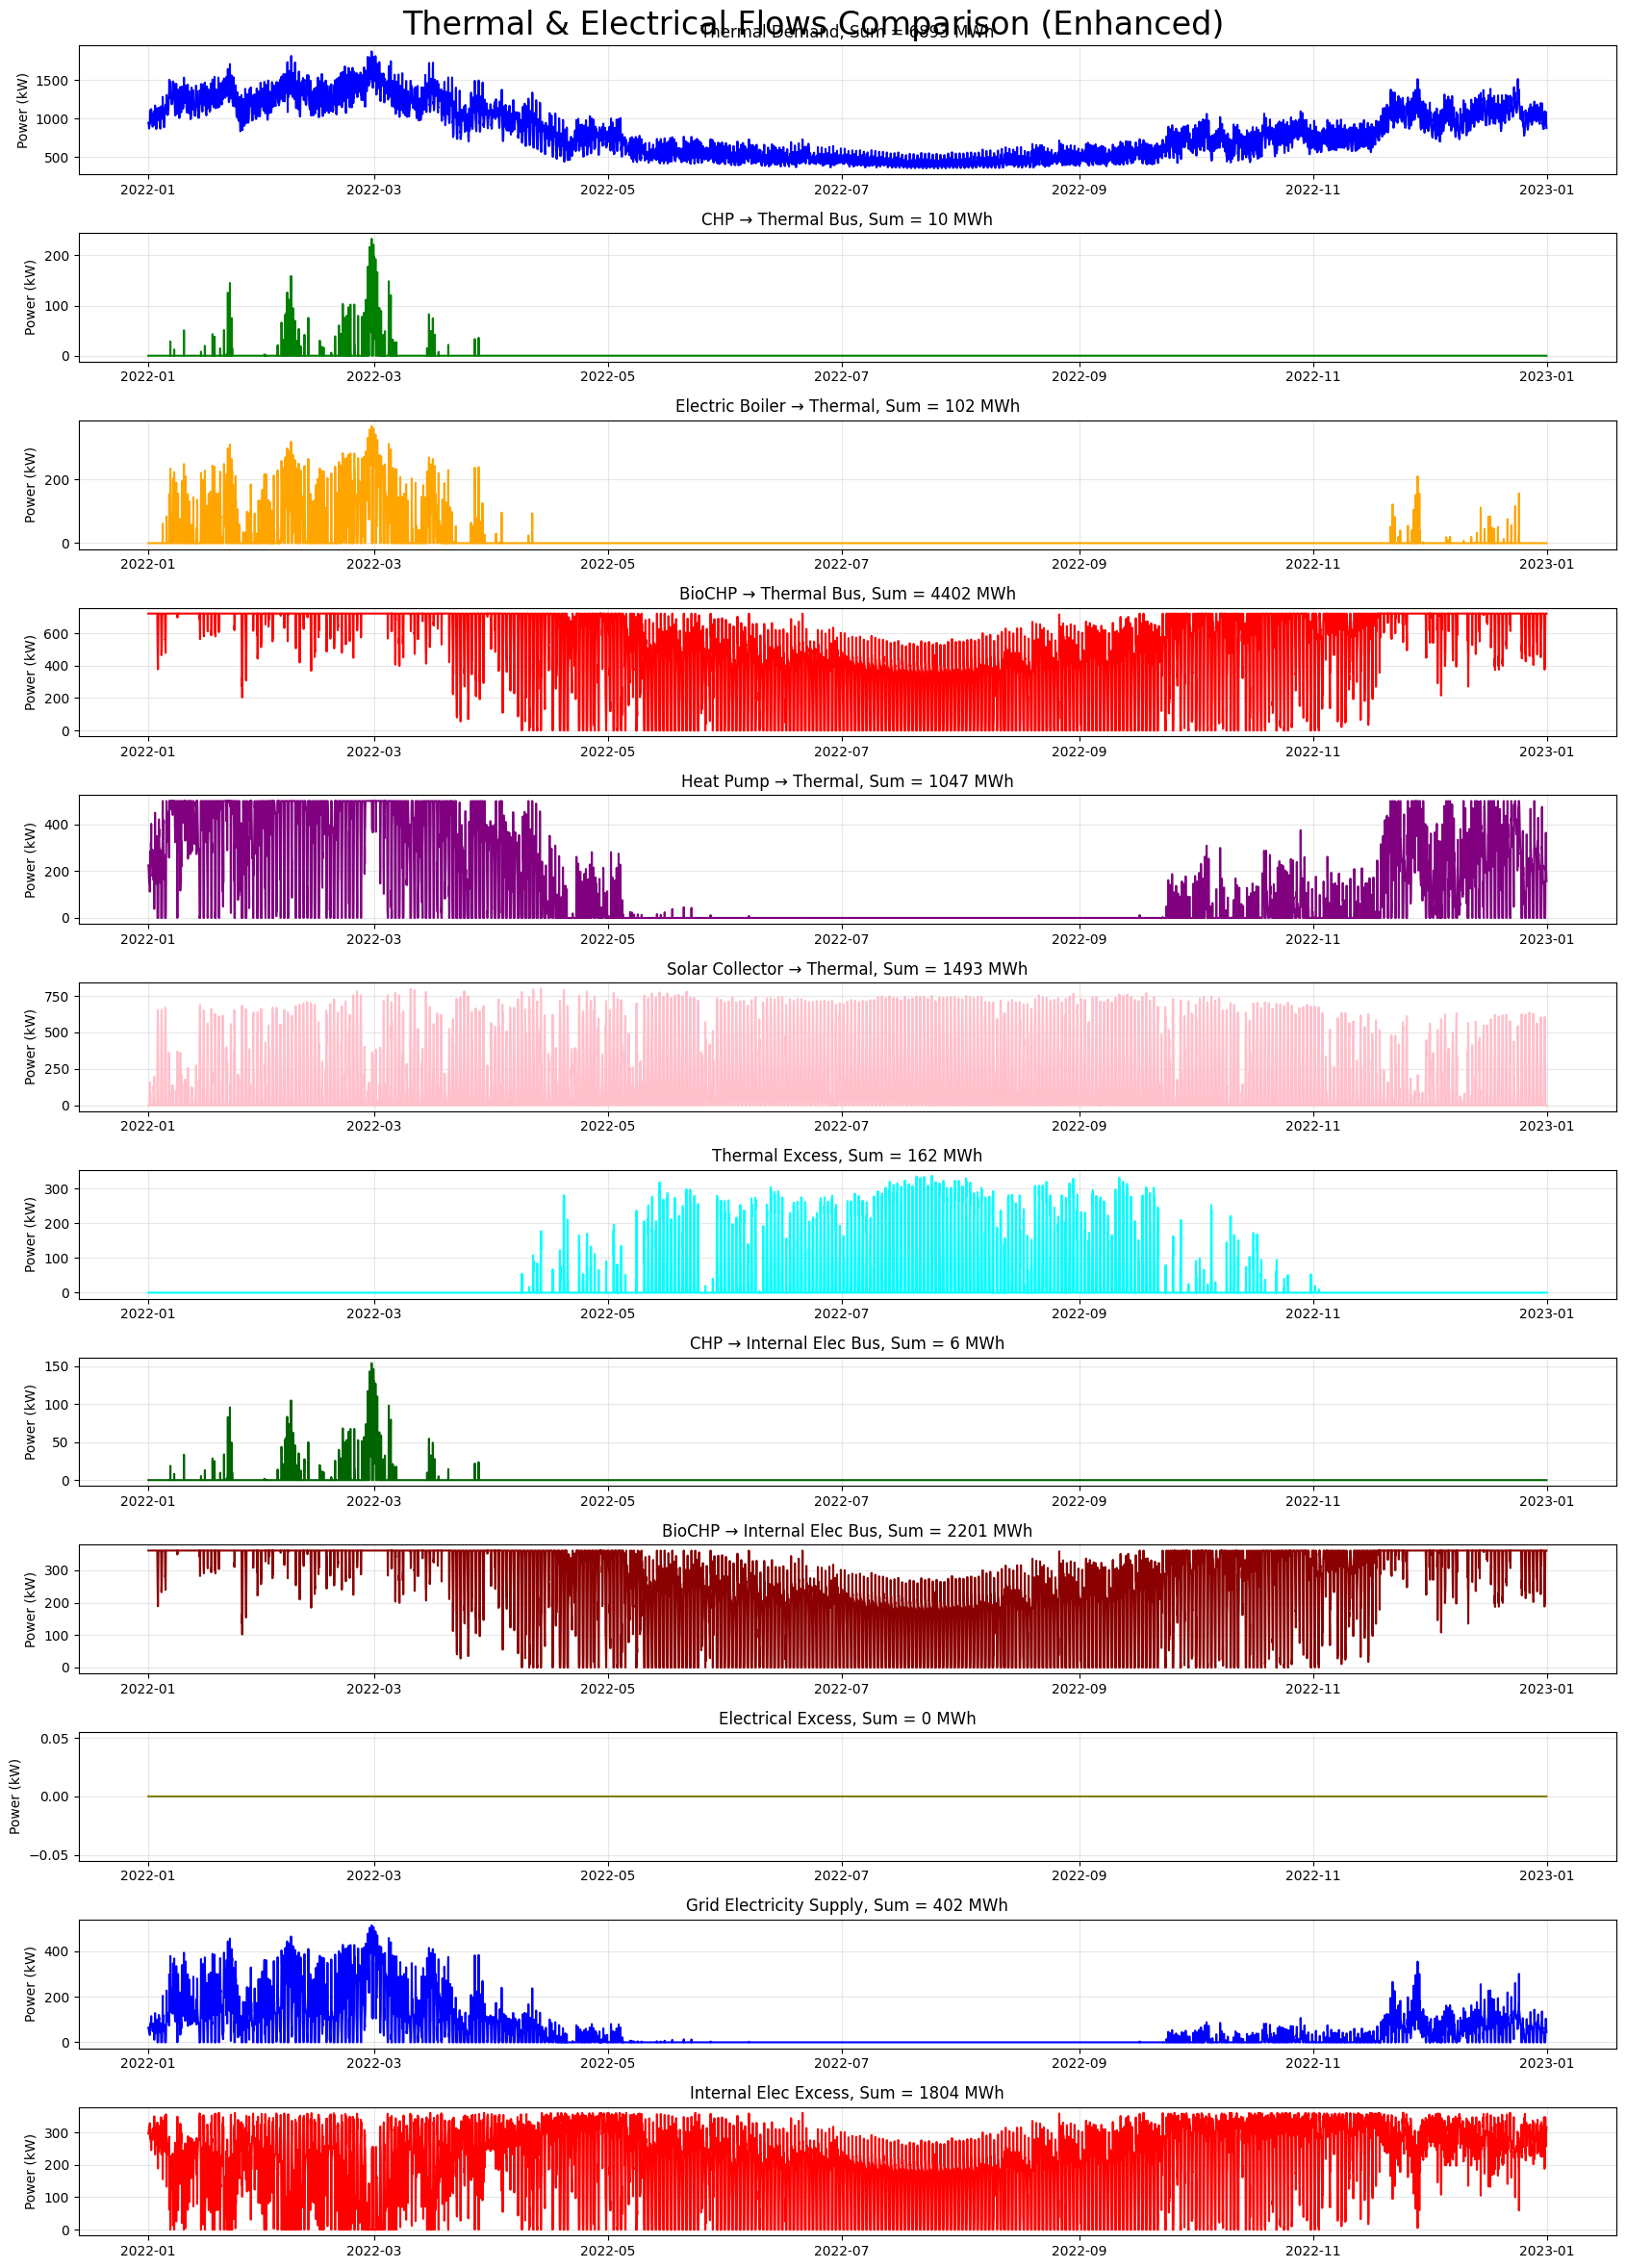

In [8]:
# Thermal sums (existing)
Sum_th_demand = thermal_results["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')].sum()
Sum_th_prod_chp = thermal_results["sequences"][(('chp', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_boiler = thermal_results["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_biochp = thermal_results["sequences"][(('biomass_chp', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_hp = thermal_results["sequences"][(('heat_pump', 'thermal_bus'), 'flow')].sum()
Sum_th_prod_sth = thermal_results["sequences"][(('solar_collector', 'thermal_bus'), 'flow')].sum()
Sum_th_excess = thermal_results["sequences"][(('thermal_bus','excess_thermal'), 'flow')].sum()

# Electrical sums (existing + NEW electrical outputs from CHP/BioCHP)
Sum_excess_elec = electrical_results["sequences"][(('electrical_bus', 'excess_electricity'), 'flow')].sum()
Sum_el_grid_prod = electrical_results["sequences"][(('electricity_grid', 'electrical_bus'), 'flow')].sum()
Sum_el_excess_int = internal_elec_results["sequences"][(('internal_elec_bus', 'excess_internal_electricity'), 'flow')].sum()

# NEW: CHP electrical production to internal bus
Sum_el_prod_chp = internal_elec_results["sequences"][(('chp', 'internal_elec_bus'), 'flow')].sum()
# NEW: Biomass CHP electrical production to internal bus
Sum_el_prod_biochp = internal_elec_results["sequences"][(('biomass_chp', 'internal_elec_bus'), 'flow')].sum()

# Updated 12-subplot figure
fig, axs = plt.subplots(12, 1, figsize=(17, 24))
fig.suptitle('Thermal & Electrical Flows Comparison (Enhanced)', fontsize=24)

# Thermal flows (0-6, unchanged)
axs[0].plot(thermal_results["sequences"][(('thermal_bus', 'thermal_demand'), 'flow')], 'blue')
axs[0].set_title(f'Thermal Demand, Sum = {int(Sum_th_demand/1000)} MWh')

axs[1].plot(thermal_results["sequences"][(('chp', 'thermal_bus'), 'flow')], 'green')
axs[1].set_title(f'CHP → Thermal Bus, Sum = {int(Sum_th_prod_chp/1000)} MWh')

axs[2].plot(thermal_results["sequences"][(('electric_boiler', 'thermal_bus'), 'flow')], 'orange')
axs[2].set_title(f'Electric Boiler → Thermal, Sum = {int(Sum_th_prod_boiler/1000)} MWh')

axs[3].plot(thermal_results["sequences"][(('biomass_chp', 'thermal_bus'), 'flow')], 'red')
axs[3].set_title(f'BioCHP → Thermal Bus, Sum = {int(Sum_th_prod_biochp/1000)} MWh')

axs[4].plot(thermal_results["sequences"][(('heat_pump', 'thermal_bus'), 'flow')], 'purple')
axs[4].set_title(f'Heat Pump → Thermal, Sum = {int(Sum_th_prod_hp/1000)} MWh')

axs[5].plot(thermal_results["sequences"][(('solar_collector', 'thermal_bus'), 'flow')], 'pink')
axs[5].set_title(f'Solar Collector → Thermal, Sum = {int(Sum_th_prod_sth/1000)} MWh')

axs[6].plot(thermal_results["sequences"][(('thermal_bus','excess_thermal'), 'flow')], 'cyan')
axs[6].set_title(f'Thermal Excess, Sum = {int(Sum_th_excess/1000)} MWh')

axs[7].plot(internal_elec_results["sequences"][(('chp', 'internal_elec_bus'), 'flow')], 'darkgreen')
axs[7].set_title(f'CHP → Internal Elec Bus, Sum = {int(Sum_el_prod_chp/1000)} MWh')

axs[8].plot(internal_elec_results["sequences"][(('biomass_chp', 'internal_elec_bus'), 'flow')], 'darkred')
axs[8].set_title(f'BioCHP → Internal Elec Bus, Sum = {int(Sum_el_prod_biochp/1000)} MWh')

axs[9].plot(electrical_results["sequences"][(('electrical_bus', 'excess_electricity'), 'flow')], 'olive')
axs[9].set_title(f'Electrical Excess, Sum = {int(Sum_excess_elec/1000)} MWh')

axs[10].plot(electrical_results["sequences"][(('electricity_grid', 'electrical_bus'), 'flow')], 'blue')
axs[10].set_title(f'Grid Electricity Supply, Sum = {int(Sum_el_grid_prod/1000)} MWh')

axs[11].plot(internal_elec_results["sequences"][(('internal_elec_bus', 'excess_internal_electricity'), 'flow')], 'red')
axs[11].set_title(f'Internal Elec Excess, Sum = {int(Sum_el_excess_int/1000)} MWh')

# Format all subplots
for ax in axs:
    ax.set_ylabel('Power (kW)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Generating an Excel file for future analysis

In [9]:
grid_supply = electrical_results["sequences"][(('electricity_grid', 'electrical_bus'), 'flow')]
internal_excess = internal_elec_results["sequences"][(('internal_elec_bus', 'excess_internal_electricity'), 'flow')]

# Per-timestep view of grid supply vs internal excess with difference
flows_comparison = pd.DataFrame(
    {
        'Grid Electricity Supply (kW)': grid_supply.values,
        'Internal Electricity Excess (kW)': internal_excess.values,
    },
    index=grid_supply.index,
)
flows_comparison['Grid minus Internal (kW)'] = (
    flows_comparison['Grid Electricity Supply (kW)']
    - flows_comparison['Internal Electricity Excess (kW)']
)

flows_comparison.to_excel('Outputs/electricity_flows_comparison.xlsx', 
                          sheet_name='Grid_vs_Internal', 
                          index=True)


## Answers to the questions

 ### Which generating units are supplying the majority of the heat demand over the simulation period? How is the load distributed among the units?


In [10]:
# Summary: which units supply most of the heat demand?

thermal_flows = {
    "NG CHP": thermal_results["sequences"][(("chp", "thermal_bus"), "flow")].sum(),
    "Biomass CHP": thermal_results["sequences"][(("biomass_chp", "thermal_bus"), "flow")].sum(),
    "Heat pump": thermal_results["sequences"][(("heat_pump", "thermal_bus"), "flow")].sum(),
    "Electric boiler": thermal_results["sequences"][(("electric_boiler", "thermal_bus"), "flow")].sum(),
    "Solar collector": thermal_results["sequences"][(("solar_collector", "thermal_bus"), "flow")].sum(),
}

heat_demand = thermal_results["sequences"][(("thermal_bus", "thermal_demand"), "flow")].sum()
excess_heat = thermal_results["sequences"][(("thermal_bus", "excess_thermal"), "flow")].sum()

total_prod = sum(thermal_flows.values())

# The delivered solar heat equals solar production minus excess
solar_delivered = max(thermal_flows["Solar collector"] - excess_heat, 0)

summary_df = (
    pd.Series(thermal_flows)
    .to_frame("kWh_produced")
    .assign(
        MWh_produced=lambda df: df["kWh_produced"] / 1000,
        MWh_supplied=lambda df: df["kWh_produced"] / 1000,
    )
)
summary_df.loc["Solar collector", "MWh_supplied"] = solar_delivered / 1000

summary_df["% of total prod"] = (summary_df["MWh_produced"] / (total_prod / 1000) * 100).round(1)
summary_df["% of demand (supplied)"] = (summary_df["MWh_supplied"] / (heat_demand / 1000) * 100).round(1)
summary_df = summary_df.sort_values("MWh_produced", ascending=False)

print("Total production (MWh):", round(total_prod / 1000, 1))
print("Total heat demand (MWh):", round(heat_demand / 1000, 1))
print("Excess heat sent to sink (assumed from solar) (MWh):", round(excess_heat / 1000, 1))
print("\nHeat by unit (sorted by produced):")
print(summary_df[["MWh_produced", "MWh_supplied", "% of total prod", "% of demand (supplied)"]])

# Main contributor by supplied heat to demand
top_unit, top_mwh = summary_df.sort_values("MWh_supplied", ascending=False).iloc[0][[0,1]].name, summary_df.sort_values("MWh_supplied", ascending=False).iloc[0].MWh_supplied
print(f"\nMain contributor to demand: {top_unit} with ~{top_mwh:.1f} MWh supplied")



Total production (MWh): 7056.3
Total heat demand (MWh): 6893.6
Excess heat sent to sink (assumed from solar) (MWh): 162.7

Heat by unit (sorted by produced):
                 MWh_produced  MWh_supplied  % of total prod  \
Biomass CHP       4402.094284   4402.094284             62.4   
Solar collector   1493.790612   1331.097845             21.2   
Heat pump         1047.810760   1047.810760             14.8   
Electric boiler    102.487248    102.487248              1.5   
NG CHP              10.123378     10.123378              0.1   

                 % of demand (supplied)  
Biomass CHP                        63.9  
Solar collector                    19.3  
Heat pump                          15.2  
Electric boiler                     1.5  
NG CHP                              0.1  

Main contributor to demand: Biomass CHP with ~4402.1 MWh supplied


C:\Users\mugol\AppData\Local\Temp\ipykernel_20908\3442870272.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  top_unit, top_mwh = summary_df.sort_values("MWh_supplied", ascending=False).iloc[0][[0,1]].name, summary_df.sort_values("MWh_supplied", ascending=False).iloc[0].MWh_supplied


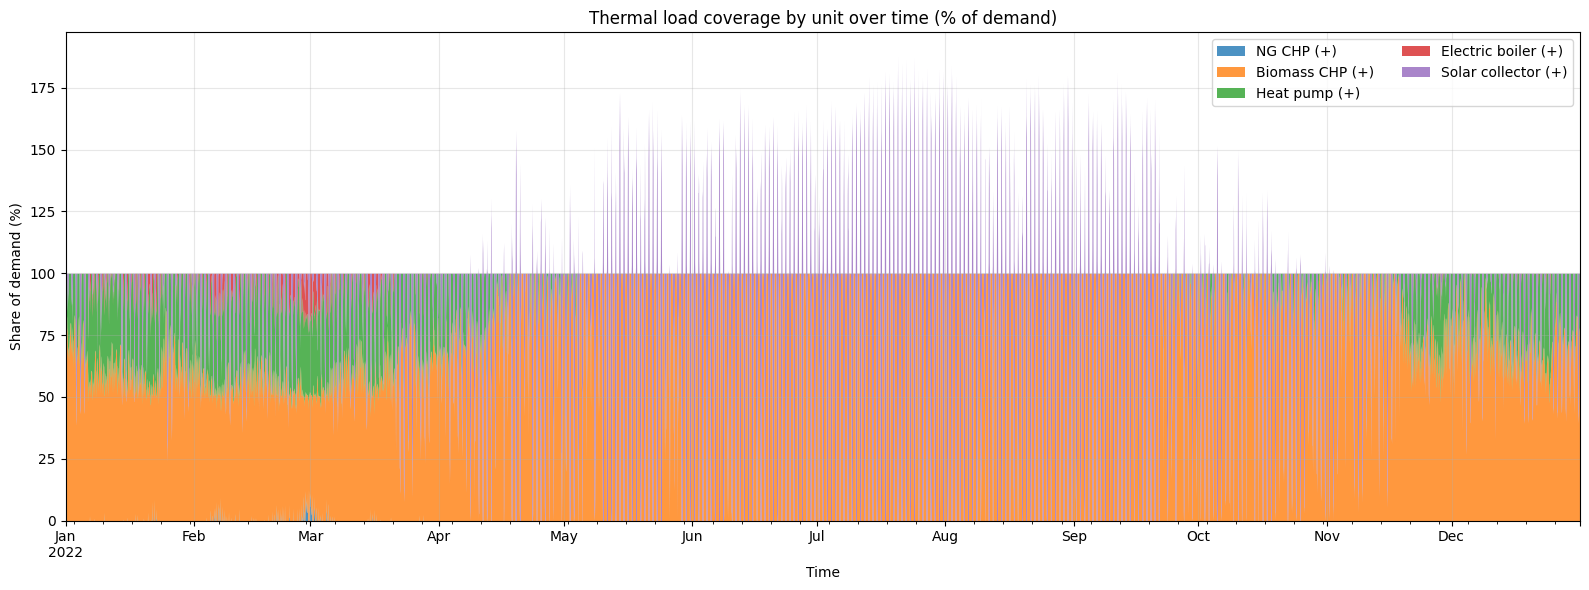

In [11]:
# How the thermal load is distributed among units over time (stacked area, %)

flows_ts = pd.DataFrame({
    "NG CHP": thermal_results["sequences"][(("chp", "thermal_bus"), "flow")],
    "Biomass CHP": thermal_results["sequences"][(("biomass_chp", "thermal_bus"), "flow")],
    "Heat pump": thermal_results["sequences"][(("heat_pump", "thermal_bus"), "flow")],
    "Electric boiler": thermal_results["sequences"][(("electric_boiler", "thermal_bus"), "flow")],
    "Solar collector": thermal_results["sequences"][(("solar_collector", "thermal_bus"), "flow")],
})

demand_ts = thermal_results["sequences"][(("thermal_bus", "thermal_demand"), "flow")]

# Compute percentage share per timestep; avoid div-by-zero
pct_ts = flows_ts.div(demand_ts.replace(0, pd.NA), axis=0) * 100
pct_ts = pct_ts.fillna(0)

pct_pos = pct_ts.clip(lower=0)

pct_pos.columns = [f"{c} (+)" for c in pct_pos.columns]

# Combine back into one DataFrame for plotting
pct_stacked = pd.concat([pct_pos], axis=1)

ax = pct_stacked.plot.area(figsize=(16, 6), linewidth=0, alpha=0.8)
plt.title("Thermal load coverage by unit over time (% of demand)")
plt.ylabel("Share of demand (%)")
plt.xlabel("Time")
plt.legend(loc="upper right", ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### What are the total operational costs for each unit, and which unit contributes most to system costs?

The code above prices grid power only after crediting internal CHP generation:
- Start from flows_comparison["Grid minus Internal (kW)"], which already nets grid supply against internal electricity (e.g., CHP output).
- Clip negatives to zero so any surplus internal generation fully offsets grid use and accrues no charge.
- Align the electricity price series to the same timestep index.
- Multiply the positive net imports by the matching €/kWh price each timestep and sum to get total grid electricity cost.

This was necessary after analysing how the model isn't capable of receiving energy from two buses simultaneously (i.e. when internal electricity production from the CHPs is not enough to fullfil the demand) and so it takes everything from the grid. 

In the case when the internal electriciy is higher than the demand, a feed-in mechanism of the excess internal electricity production is not considered in this analysis. Because of that, the costs below are only related to the generation side of the system.

Moreover, the optimization model is believed to do not perform a "smart" optimization. Infact, it optimize the generation based on the prices of the fuels, but not considering the internally generated electricity when it's lower than the demand, and so taking it all from the grid, the costs result higher compared to a real situation. A possible solution would be to have a storage system which connecte both grid and internal electricity and acting as a buffer, since the sinks cannot have a bus connected in output in oemof.

In [12]:

# STEP 2: CREATE COST SERIES (Scenario B) 
# Fuel Price is set to 0. Only CO2 Cost is added.
gas_cost = (data["gas_price"] / 1000 *0) + natural_gas_co2_cost
biomass_cost = (data["biomass_price"] / 4.167 / 1000 * 0) # Assumed zero
elec_price = (data["electricity_price"] / 1000 * 0) + grid_co2_cost

# STEP 3: EXTRACT ACTUAL FLOWS 

# A. Gas Flow 
gas_bus_res = views.node(results, "gas_bus")
flow_gas_to_chp = gas_bus_res["sequences"][(("gas_bus", "chp"), "flow")]

# B. Biomass Flow
biomass_bus_res = views.node(results, "biomass_bus")
flow_biomass_to_biochp = biomass_bus_res["sequences"][(("biomass_bus", "biomass_chp"), "flow")]

# C. Grid Flow (CRITICAL FIX)
# We look at the connection from "electricity_grid" (Source) to "electrical_bus" (Bus)
grid_src_res = views.node(results, "electricity_grid") 
flow_grid_import = grid_src_res["sequences"][(("electricity_grid", "electrical_bus"), "flow")]

# STEP 4: CALCULATE FINAL COSTS
# Align prices to the exact index of the flows
grid_cost_total = (flow_grid_import * pd.Series(elec_price.values, index=flow_grid_import.index)).sum()
gas_cost_total = (flow_gas_to_chp * gas_cost.values).sum()
biomass_cost_total = (flow_biomass_to_biochp * biomass_cost.values).sum()

costs = {
    "NG CHP (CO2 cost)": gas_cost_total,
    "Biomass CHP (CO2 cost)": biomass_cost_total,
    "Grid electricity (CO2 cost)": grid_cost_total, # Should now be ~50-500 EUR, not Trillions
    "Heat pump": 0.0,
    "Electric boiler": 0.0,
    "Solar collector": 0.0,
}

costs_series = pd.Series(costs).sort_values(ascending=False)

print("--- Scenario B Results (Corrected) ---")
print(costs_series)
print(f"\nTotal Emission Cost: {costs_series.sum():.2f} EUR")

--- Scenario B Results (Corrected) ---
Grid electricity (CO2 cost)    11727.613207
NG CHP (CO2 cost)                349.640320
Biomass CHP (CO2 cost)             0.000000
Heat pump                          0.000000
Electric boiler                    0.000000
Solar collector                    0.000000
dtype: float64

Total Emission Cost: 12077.25 EUR


In [13]:
grid_src_res = views.node(results, "electricity_grid")
flow_grid_import = grid_src_res["sequences"][(("electricity_grid", "electrical_bus"), "flow")]

dt_h = (flow_grid_import.index[1] - flow_grid_import.index[0]).total_seconds() / 3600
grid_import_MWh = flow_grid_import.sum() * dt_h / 1000

elec_price_series = pd.Series(elec_price.values, index=flow_grid_import.index)
avg_grid_co2_cost = elec_price_series.mean()

print("Grid import (MWh):", grid_import_MWh)
print("Avg grid CO2 cost (€/kWh):", avg_grid_co2_cost)
print("Implied €/MWh:", avg_grid_co2_cost * 1000)
print("Recomputed grid CO2 cost (€):", (flow_grid_import * dt_h * elec_price_series).sum())


Grid import (MWh): 402.8969755206899
Avg grid CO2 cost (€/kWh): 0.028296158333333335
Implied €/MWh: 28.296158333333334
Recomputed grid CO2 cost (€): 11727.613207418599


In [14]:
grid_src_res = views.node(results, "electricity_grid")
flow_grid_import = grid_src_res["sequences"][(("electricity_grid", "electrical_bus"), "flow")]

dt_h = (flow_grid_import.index[1] - flow_grid_import.index[0]).total_seconds() / 3600
grid_import_MWh = flow_grid_import.sum() * dt_h / 1000

print("Annual grid import (MWh):", grid_import_MWh)



Annual grid import (MWh): 402.8969755206899


### In Scenario B, which low-carbon units dominate operation?


In [15]:
# Define low-carbon units (emission factor = 0 or very low)
# Emission factors: Biomass = 0.0, Solar = 0.0, Heat pump & Electric boiler use electricity (indirect emissions)

low_carbon_units = {
    "Biomass CHP": {
        "emission_factor": 0.0,
        "thermal_flow": thermal_results["sequences"][(("biomass_chp", "thermal_bus"), "flow")],
        "electrical_flow": internal_elec_results["sequences"][(("biomass_chp", "internal_elec_bus"), "flow")],
    },
    "Solar collector": {
        "emission_factor": 0.0,
        "thermal_flow": thermal_results["sequences"][(("solar_collector", "thermal_bus"), "flow")],
        "electrical_flow": None,  # No electrical output
    },
    "Heat pump": {
        "emission_factor": 0.0,  # Indirect emissions from grid electricity, but considered low-carbon
        "thermal_flow": thermal_results["sequences"][(("heat_pump", "thermal_bus"), "flow")],
        "electrical_flow": None,  # Consumes electricity, doesn't produce
    },
    "Electric boiler": {
        "emission_factor": 0.0,  # Indirect emissions from grid electricity, but considered low-carbon
        "thermal_flow": thermal_results["sequences"][(("electric_boiler", "thermal_bus"), "flow")],
        "electrical_flow": None,  # Consumes electricity, doesn't produce
    },
}

# High-carbon units for comparison
high_carbon_units = {
    "NG CHP": {
        "emission_factor": 0.2,
        "thermal_flow": thermal_results["sequences"][(("chp", "thermal_bus"), "flow")],
        "electrical_flow": internal_elec_results["sequences"][(("chp", "internal_elec_bus"), "flow")],
    },
}

# Calculate total thermal production from low-carbon units
low_carbon_thermal_total = sum(
    unit["thermal_flow"].sum() for unit in low_carbon_units.values()
) / 1000  # MWh

high_carbon_thermal_total = sum(
    unit["thermal_flow"].sum() for unit in high_carbon_units.values()
) / 1000  # MWh

total_thermal_demand = thermal_results["sequences"][(("thermal_bus", "thermal_demand"), "flow")].sum() / 1000  # MWh

# Calculate individual contributions
low_carbon_contributions = {}
for unit_name, unit_data in low_carbon_units.items():
    thermal_mwh = unit_data["thermal_flow"].sum() / 1000
    pct_of_demand = (thermal_mwh / total_thermal_demand) * 100
    low_carbon_contributions[unit_name] = {
        "MWh_thermal": thermal_mwh,
        "% of demand": pct_of_demand,
    }
    if unit_data["electrical_flow"] is not None:
        elec_mwh = unit_data["electrical_flow"].sum() / 1000
        low_carbon_contributions[unit_name]["MWh_electrical"] = elec_mwh

# Sort by contribution
low_carbon_sorted = sorted(
    low_carbon_contributions.items(),
    key=lambda x: x[1]["% of demand"],
    reverse=True
)

print("LOW-CARBON UNITS  - SCENARIO B")

print(f"\nTotal thermal demand: {total_thermal_demand:.1f} MWh")
print(f"Low-carbon units total: {low_carbon_thermal_total:.1f} MWh ({low_carbon_thermal_total/total_thermal_demand*100:.1f}% of demand)")
print(f"High-carbon units total: {high_carbon_thermal_total:.1f} MWh ({high_carbon_thermal_total/total_thermal_demand*100:.1f}% of demand)")


print("LOW-CARBON UNITS RANKED BY OPERATION DOMINANCE:")
print("-" * 70)
for i, (unit_name, data) in enumerate(low_carbon_sorted, 1):
    print(f"\n{i}. {unit_name}:")
    print(f"   • Thermal production: {data['MWh_thermal']:.1f} MWh")
    print(f"   • Share of demand: {data['% of demand']:.1f}%")
    if "MWh_electrical" in data:
        print(f"   • Electrical production: {data['MWh_electrical']:.1f} MWh")

top_unit = low_carbon_sorted[0][0]
top_pct = low_carbon_sorted[0][1]["% of demand"]


LOW-CARBON UNITS  - SCENARIO B

Total thermal demand: 6893.6 MWh
Low-carbon units total: 7046.2 MWh (102.2% of demand)
High-carbon units total: 10.1 MWh (0.1% of demand)
LOW-CARBON UNITS RANKED BY OPERATION DOMINANCE:
----------------------------------------------------------------------

1. Biomass CHP:
   • Thermal production: 4402.1 MWh
   • Share of demand: 63.9%
   • Electrical production: 2201.0 MWh

2. Solar collector:
   • Thermal production: 1493.8 MWh
   • Share of demand: 21.7%

3. Heat pump:
   • Thermal production: 1047.8 MWh
   • Share of demand: 15.2%

4. Electric boiler:
   • Thermal production: 102.5 MWh
   • Share of demand: 1.5%


### What is the trade-off between economic and environmental outcomes considering Step 4 and Step 5 (both scenarios)?

This analysis compares STEP_4, Scenario A, and Scenario B across environmental (emissions) and economic (costs) dimensions.


In [16]:
# Export key results to CSV for easy comparison with Scenario B and STEP_4
from pathlib import Path

# Create Outputs directory if it doesn't exist
output_dir = Path("Outputs")
output_dir.mkdir(exist_ok=True)

# Extract key flows for export
scenario_a_results = {}

# Gas flows
gas_bus_res = views.node(results, "gas_bus")
scenario_a_results["gas_bus_chp_flow"] = gas_bus_res["sequences"][(("gas_bus", "chp"), "flow")]

# Biomass flows
biomass_bus_res = views.node(results, "biomass_bus")
scenario_a_results["biomass_bus_biomass_chp_flow"] = biomass_bus_res["sequences"][(("biomass_bus", "biomass_chp"), "flow")]

# Grid electricity flows
grid_src_res = views.node(results, "electricity_grid")
scenario_a_results["electricity_grid_electrical_bus_flow"] = grid_src_res["sequences"][(("electricity_grid", "electrical_bus"), "flow")]

# Thermal flows
scenario_a_results["chp_thermal_bus_flow"] = thermal_results["sequences"][(("chp", "thermal_bus"), "flow")]
scenario_a_results["biomass_chp_thermal_bus_flow"] = thermal_results["sequences"][(("biomass_chp", "thermal_bus"), "flow")]
scenario_a_results["heat_pump_thermal_bus_flow"] = thermal_results["sequences"][(("heat_pump", "thermal_bus"), "flow")]
scenario_a_results["electric_boiler_thermal_bus_flow"] = thermal_results["sequences"][(("electric_boiler", "thermal_bus"), "flow")]
scenario_a_results["solar_collector_thermal_bus_flow"] = thermal_results["sequences"][(("solar_collector", "thermal_bus"), "flow")]

# Create DataFrame
scenario_a_df = pd.DataFrame(scenario_a_results, index=thermal_results["sequences"].index)

# Export to CSV
output_file = output_dir / "STEP_5_Scenario_B_results.csv"
scenario_a_df.to_csv(output_file)
print(f"Scenario B results exported to: {output_file}")
print(f"Total rows: {len(scenario_a_df)}")
print(f"Columns: {list(scenario_a_df.columns)}")


Scenario B results exported to: Outputs\STEP_5_Scenario_B_results.csv
Total rows: 8760
Columns: ['gas_bus_chp_flow', 'biomass_bus_biomass_chp_flow', 'electricity_grid_electrical_bus_flow', 'chp_thermal_bus_flow', 'biomass_chp_thermal_bus_flow', 'heat_pump_thermal_bus_flow', 'electric_boiler_thermal_bus_flow', 'solar_collector_thermal_bus_flow']


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(r"OEMOF_files/Example_1.csv")

el_price_kwh = data["electricity_price"] / 1000
co2_price_kg = data["co2_price"] / 1000
gas_price_kwh = data["gas_price"] / 1000

biomass_cost_per_mwh = data["biomass_price"] / 4.167
biomass_cost_per_kwh = biomass_cost_per_mwh / 1000

grid_emission_factor = 0.35
biomass_emission_factor = 0.0
natural_gas_emission_factor = 0.2

def compute_kpis(grid_flow, biomass_flow, gas_flow):
    grid_flow = grid_flow.fillna(0)
    biomass_flow = biomass_flow.fillna(0)
    gas_flow = gas_flow.fillna(0)

    elec_cost = (grid_flow * el_price_kwh).sum()
    biomass_cost = (biomass_flow * biomass_cost_per_kwh).sum()
    gas_cost = (gas_flow * gas_price_kwh).sum()  

    emissions_hourly = (
        grid_flow * grid_emission_factor
        + biomass_flow * biomass_emission_factor
        + gas_flow * natural_gas_emission_factor
    )
    emissions_kg = emissions_hourly.sum()
    carbon_cost = (emissions_hourly * co2_price_kg).sum()

    total_cost = elec_cost + biomass_cost + gas_cost + carbon_cost 
    return elec_cost, biomass_cost, gas_cost, carbon_cost, total_cost, emissions_kg

step4_df  = pd.read_csv("Outputs/STEP_4_results.csv")
step5A_df = pd.read_csv("Outputs/STEP_5_Scenario_A_results.csv")
step5B_df = pd.read_csv("Outputs/STEP_5_Scenario_B_results.csv")

def kpis_from_df(df):
    grid = df["electricity_grid_electrical_bus_flow"]
    bio  = df["biomass_bus_biomass_chp_flow"]
    gas  = df["gas_bus_chp_flow"]
    return compute_kpis(grid, bio, gas)


elec4, bio4, gas4, carb4, tot4, emis4 = kpis_from_df(step4_df)
elecA, bioA, gasA, carbA, totA, emisA = kpis_from_df(step5A_df)
elecB, bioB, gasB, carbB, totB, emisB = kpis_from_df(step5B_df)

summary = pd.DataFrame({
    "Scenario": ["Step 4", "Step 5 - A", "Step 5 - B"],
    "ElecCost_EUR":   [elec4, elecA, elecB],
    "BiomassCost_EUR":[bio4,  bioA,  bioB],
    "GasCost_EUR":    [gas4,  gasA,  gasB],     
    "CarbonCost_EUR": [carb4, carbA, carbB],
    "TotalCost_EUR":  [tot4,  totA,  totB],
    "Emissions_kgCO2":[emis4, emisA, emisB],
})

summary["ΔCost_vs_Step4_EUR"] = summary["TotalCost_EUR"] - tot4
summary["ΔEmissions_vs_Step4_kg"] = summary["Emissions_kgCO2"] - emis4
summary["AbatementCost_EUR_per_tCO2"] = summary["ΔCost_vs_Step4_EUR"] / (-summary["ΔEmissions_vs_Step4_kg"] / 1000)

print(summary)


     Scenario   ElecCost_EUR  BiomassCost_EUR   GasCost_EUR  CarbonCost_EUR  \
0      Step 4  145584.560599    247610.567367  12867.923006    25879.739706   
1  Step 5 - A  137605.443452    258606.066307  10421.365457    23822.497402   
2  Step 5 - B   82641.951772    380310.521270   2005.580093    12077.253528   

   TotalCost_EUR  Emissions_kgCO2  ΔCost_vs_Step4_EUR  ΔEmissions_vs_Step4_kg  \
0  431942.790678    317993.439256            0.000000                0.000000   
1  430455.372618    292062.893879        -1487.418060           -25930.545377   
2  477035.306664    145063.292645        45092.515986          -172930.146611   

   AbatementCost_EUR_per_tCO2  
0                         NaN  
1                  -57.361619  
2                  260.755669  


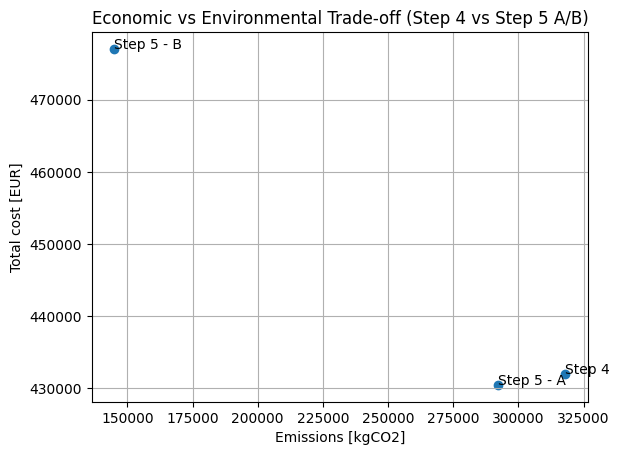

In [18]:

plt.figure()
plt.scatter(summary["Emissions_kgCO2"], summary["TotalCost_EUR"])
for _, r in summary.iterrows():
    plt.annotate(r["Scenario"], (r["Emissions_kgCO2"], r["TotalCost_EUR"]))
plt.xlabel("Emissions [kgCO2]")
plt.ylabel("Total cost [EUR]")
plt.title("Economic vs Environmental Trade-off (Step 4 vs Step 5 A/B)")
plt.grid(True)
plt.show()
